In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [11]:
word_embeddings=pickle.load(open("../data/word_embeddings_subset.p","rb"))
print(len(word_embeddings))
countryVector=word_embeddings["country"]
print(countryVector.shape)

243
(300,)


#### word embedding

In [12]:
def vec(w):
    return word_embeddings[w]

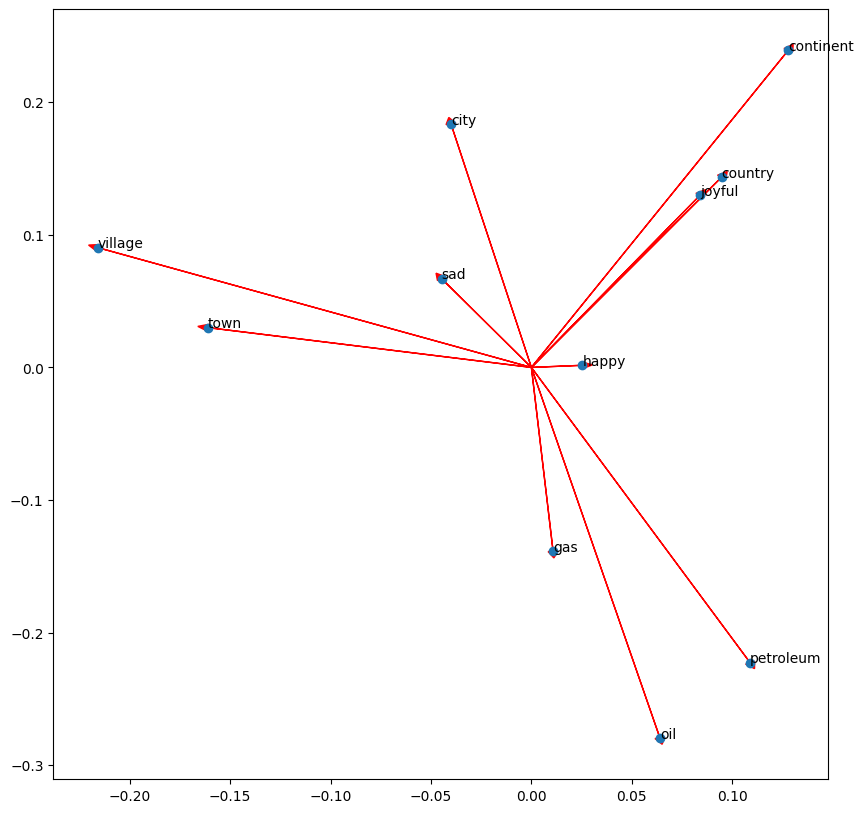

In [18]:
words = ['oil', 'gas', 'happy', 'sad', 'city', 'town', 'village', 'country', 'continent', 'petroleum', 'joyful']
bag2d=np.array([vec(word) for word in words])
fig,ax=plt.subplots(figsize=(10,10))
# choose random col
col1=3
col2=2
for word in bag2d:
    ax.arrow(0,0,word[col1],word[col2],head_width=0.005,head_length=0.005,fc="r", ec="r",width=1e-5)
ax.scatter(bag2d[:,col1],bag2d[:,col2])
#top-label
for i in range(0,len(words)):
    ax.annotate(words[i],(bag2d[i,col1],bag2d[i,col2]))
plt.show()

#### Word Distance

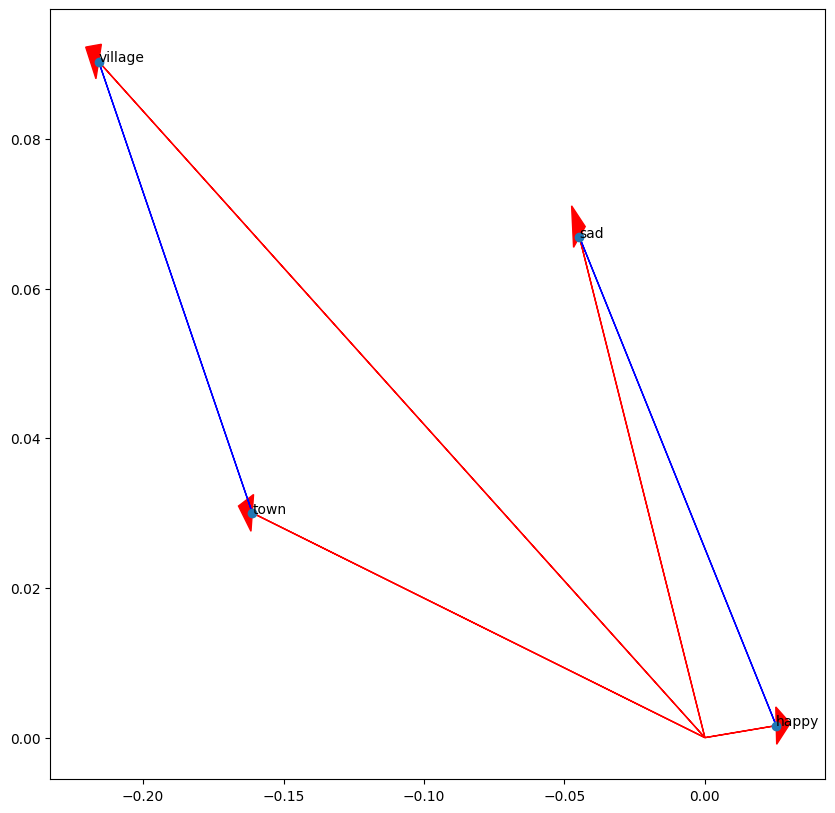

In [25]:
words = ['sad', 'happy', 'town', 'village']
bag2d=np.array([vec(word) for word in words])
fig,ax=plt.subplots(figsize=(10,10))
# choose random col
col1=3
col2=2
for word in bag2d:
    ax.arrow(0,0,word[col1],word[col2],head_width=0.005,head_length=0.005,fc="r", ec="r",width=1e-5)

village = vec('village')
town = vec('town')
diff = town - village
ax.arrow(village[col1], village[col2], diff[col1], diff[col2], fc='b', ec='b', width = 1e-5)
# just the differnce
sad = vec('sad')
happy = vec('happy')
diff = happy - sad
ax.arrow(sad[col1], sad[col2], diff[col1], diff[col2], fc='b', ec='b', width = 1e-5)


ax.scatter(bag2d[:, col1], bag2d[:, col2]);

for i in range(0,len(words)):
    ax.annotate(words[i],(bag2d[i,col1],bag2d[i,col2]))
plt.show()

#### normalization

In [31]:
print(vec("town")[:10])
town_norm=np.linalg.norm(vec("town"))
print(town_norm)
print(vec("sad")[:10])
sad_norm=np.linalg.norm(vec("sad"))
print(sad_norm)

[ 0.12353516  0.15917969  0.0300293  -0.16113281  0.015625    0.11181641
  0.03979492 -0.19628906 -0.03930664  0.06787109]
2.3858097
[ 0.18945312  0.04589844  0.06689453 -0.04467773  0.17871094  0.01965332
  0.34765625 -0.0246582   0.40625     0.10595703]
2.9004838


#### predicting capital

In [39]:
capital=vec("France")-vec("Paris")
country=vec("Cairo")+capital
print(country[0:10]) #the closest to this vector
vec("Egypt")[0:10]

[ 0.11889648  0.11572266  0.21676636  0.1550293  -0.12316895  0.05004883
 -0.06933594 -0.22363281 -0.21484375  0.23815918]


array([ 0.21972656,  0.20800781, -0.13671875, -0.06298828, -0.03637695,
       -0.04052734,  0.046875  , -0.19042969, -0.16113281,  0.07324219],
      dtype=float32)

#### closest words

In [50]:
keys=word_embeddings.keys()
data=[]
for key in keys:
    data.append(word_embeddings[key])

embedding=pd.DataFrame(data=data,index=keys)
def find_closest_word(v,k = 1):
    diff=embedding.values - v
    delta=np.sum(diff * diff, axis=1)
    i=np.argmin(delta)
    return embedding.iloc[i].name

In [47]:
embedding.head(10)

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
country,-0.080078,0.133789,0.143555,0.094727,-0.047363,-0.023560,-0.008545,-0.186523,0.045898,-0.081543,...,-0.145508,0.067383,-0.244141,-0.077148,0.047607,-0.075195,-0.149414,-0.044189,0.097168,0.067383
city,-0.010071,0.057373,0.183594,-0.040039,-0.029785,-0.079102,0.071777,0.013306,-0.143555,0.011292,...,0.024292,-0.168945,-0.062988,0.117188,-0.020508,0.030273,-0.247070,-0.122559,0.076172,-0.234375
China,-0.073242,0.135742,0.108887,0.083008,-0.127930,-0.227539,0.151367,-0.045654,-0.065430,0.034424,...,0.140625,0.087402,0.152344,0.079590,0.006348,-0.037842,-0.183594,0.137695,0.093750,-0.079590
Iraq,0.191406,0.125000,-0.065430,0.060059,-0.285156,-0.102539,0.117188,-0.351562,-0.095215,0.200195,...,-0.100586,-0.077148,-0.123047,0.193359,-0.153320,0.089355,-0.173828,-0.054688,0.302734,0.105957
oil,-0.139648,0.062256,-0.279297,0.063965,0.044434,-0.154297,-0.184570,-0.498047,0.047363,0.110840,...,-0.195312,-0.345703,0.217773,-0.091797,0.051025,0.061279,0.194336,0.204102,0.235352,-0.051025
town,0.123535,0.159180,0.030029,-0.161133,0.015625,0.111816,0.039795,-0.196289,-0.039307,0.067871,...,-0.007935,-0.091797,-0.265625,0.029297,0.089844,-0.049805,-0.202148,-0.079590,0.068848,-0.164062
Canada,-0.136719,-0.154297,0.269531,0.273438,0.086914,-0.076172,-0.018677,0.006256,0.077637,-0.211914,...,0.105469,0.030762,-0.039307,0.183594,-0.117676,0.191406,0.074219,0.020996,0.285156,-0.257812
London,-0.267578,0.092773,-0.238281,0.115234,-0.006836,0.221680,-0.251953,-0.055420,0.020020,0.149414,...,-0.008667,-0.008484,-0.053223,0.197266,-0.296875,0.064453,0.091797,0.058350,0.022583,-0.101074
England,-0.198242,0.115234,0.062500,-0.058350,0.226562,0.045898,-0.062256,-0.202148,0.080566,0.021606,...,0.135742,0.109375,-0.121582,0.008545,-0.171875,0.086914,0.070312,0.003281,0.069336,0.056152
Australia,0.048828,-0.194336,-0.041504,0.084473,-0.114258,-0.208008,-0.164062,-0.269531,0.079102,0.275391,...,0.021118,0.171875,0.042236,0.221680,-0.239258,-0.106934,0.030884,0.006622,0.051270,-0.135742


In [46]:
find_closest_word(country)

'Egypt'

#### Represent a snetence as a vector

In [51]:
doc = "Spain petroleum city king"
vdoc = [vec(x) for x in doc.split(" ")]
doc2vec = np.sum(vdoc, axis = 0)
find_closest_word(doc2vec)

'petroleum'